# Generate Rare Reward plot

In [1]:
# ---------------------------------------------------------------------------------------------------------------
import os
import rpy2
import pickle

import pandas as pd
import sys, os
import matplotlib

#matplotlib.use('Qt5Agg')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
 #simulation as sim,import_photometry_data as pi,
# from analysis_code import plot_behaviour as pl, saving as sv,  \
#   model_fitting as mf, plot_models as pm, import_behaviour_data as di, \
#   plot_photometry as plp, parallel_processing as pp

from RL_agents_two_step import mf, mb, latent_state, mf_forget_diffa, mb_forget_0_diffa, latent_state_rewasym

#dir_folder_variables = './data_variables/'
from analysis_code import saving as sv
from analysis_code import plot_photometry as plp

dir_folder_variables = 'data'

from functools import partial
from scipy import stats
from analysis_code import parallel_processing as pp

import pandas as pd
import numpy as np
#import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.datasets import load_iris
#from sklearn.feature_selection import GenericUnivariateSelect, SelectKBest, f_regression, r_regression, mutual_info_regression, VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.decomposition import non_negative_factorization, PCA
#from tabulate import tabulate
from collections import defaultdict
from scipy.stats import ttest_rel


from pandas.core.frame import DataFrame as DF

import seaborn as sns
sns.set(color_codes=True)
#np.random.seed(sum(map(ord, "distributions")))
from sklearn import linear_model  # packages for the logistic regression function to plot the logistic regression
from sklearn.linear_model import LogisticRegression # packages for the logistic regression function to plot the logistic regression
import scipy
from scipy import stats, integrate
from scipy.stats import mode
from scipy.stats.stats import pearsonr # Pearson's correlation
from copy import copy as copy
import operator as operator
import pylab

# Plotting tools
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
%pylab inline
figsize(5, 5)

import glob

from IPython.display import clear_output

import os
# Added to avoid OMP:error#15
os.environ['KMP_DUPLICATE_LIB_OK']='True'

from pymer4.models import lmer


/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_71960/1506862162.py:56: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr # Pearson's correlation
/opt/anaconda3/envs/base_macAir_conda/lib/python3.12/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['pylab', 'copy']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
# !pip install Qt5Agg

In [3]:
# function to split the dataframe into subjectwise dataframes
def split_subjects(df):
    subjects = df.keys()
    subject_data = pd.DataFrame()
    for subject in subjects:

        subject_data = pd.concat([subject_data ,df_stim_sims[subject]])

    return subject_data

In [4]:
import random
def bernoulli(p):
  if random.random() <= p:
    return 1
  else:
    return 0


In [5]:

def extractTrialTypes(outStim_fullDF, metric = 'correct_next_fix'):

    # outDF0 = outStim_fullDF.loc[(outStim_fullDF['free_choice']==1) & (outStim_fullDF['free_next']==1)   &  (outStim_fullDF['rew_state'] != 2)  ]#& (outStim_fullDF['threshCrossed']==1)]
    outDF0 = outStim_fullDF

    outDF = outDF0.loc[ (outDF0['stim']==0)]
    RR_0 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 1) ][metric].values
    RN_0 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 0) ][metric].values
    CR_0 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 1) ][metric].values
    CN_0 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 0) ][metric].values

    M0 = [CR_0,RR_0,CN_0,RN_0]

    outDF = outDF0.loc[ (outDF0['stim']==1)]

    RR_1 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 1) ][metric].values
    RN_1 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 0) ][metric].values
    CR_1 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 1) ][metric].values
    CN_1 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 0) ] [metric].values

    M1 = [CR_1, RR_1,CN_1,RN_1]


    return M0,M1


def extractTrialTypesMerged(outStim_fullDF, metric = 'correct_next_fix'):

    # outDF0 = outStim_fullDF.loc[(outStim_fullDF['correct']==1) & (outStim_fullDF['free_choice']==1) & (outStim_fullDF['free_next']==1)   &  (outStim_fullDF['rew_state'] != 2)  ]#& (outStim_fullDF['threshCrossed']==1)]
    outDF = outStim_fullDF

    # outDF = outDF0.loc[ (outDF0['stim']==0)]
    RR_0 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 1) ][metric].values
    RN_0 =   outDF.loc[(outDF['common_transition']== False) & (outDF['outcomes']== 0) ][metric].values
    CR_0 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 1) ][metric].values
    CN_0 =   outDF.loc[(outDF['common_transition']== True) & (outDF['outcomes']== 0) ][metric].values

    M0 = [CR_0,RR_0,CN_0,RN_0]

    return M0

def perm_pairwiseTrialTypes(means_1, means_2,labelsSamples = ['Stim', 'No-stim']):

    # calculate for the conditions
    # CR: common reward

    condLabels = ['CR', 'RR','CN', 'RN']

    for i in range(len(condLabels)):
        print("Condition: "  + condLabels[i])

        x = means_1[i]
        x = x[~numpy.isnan(x)]

        y = means_2[i]
        y = y[~numpy.isnan(y)]

        res = permutation_test((x, y), statistic)


        if res.pvalue < 0.001:
            significant = '***'
        elif res.pvalue < 0.01:
            significant = '**'
        elif res.pvalue < 0.05:
            significant = '*'
        else:
            significant = ''

        print(""  + labelsSamples[0] + " - " + labelsSamples[1] + ": " + str(res.statistic) + " p-value: " + str(res.pvalue), significant)


In [6]:
def plotTrialTypes (M0,M1,M0_YFP,M1_YFP, metric = 'P(Correct Next) / After Threshold',locLegend = 'lower right'):
    colors = ['blue', 'lightblue','green', 'lightgreen']
    colors = ['#e97d68', '#e97d68','#a61945', '#a61945']

    plt.bar(0, np.nanmean(M0[0]), yerr=stats.sem(M0[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[0])
    plt.bar(1, np.nanmean(M1[0]), yerr=stats.sem(M1[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[1],hatch='//')
    plt.bar(2, np.nanmean(M0_YFP[0]), yerr=stats.sem(M0_YFP[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[2])
    plt.bar(3, np.nanmean(M1_YFP[0]), yerr=stats.sem(M1_YFP[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[3],hatch='//')

    plt.bar(4, np.nanmean(M0[1]), yerr=stats.sem(M0[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[0])
    plt.bar(5, np.nanmean(M1[1]), yerr=stats.sem(M1[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[1],hatch='//')
    plt.bar(6, np.nanmean(M0_YFP[1]), yerr=stats.sem(M0_YFP[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[2])
    plt.bar(7, np.nanmean(M1_YFP[1]), yerr=stats.sem(M1_YFP[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[3],hatch='//')

    plt.bar(8, np.nanmean(M0[2]), yerr=stats.sem(M0[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[0])
    plt.bar(9, np.nanmean(M1[2]), yerr=stats.sem(M1[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[1],hatch='//')
    plt.bar(10, np.nanmean(M0_YFP[2]), yerr=stats.sem(M0_YFP[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[2])
    plt.bar(11, np.nanmean(M1_YFP[2]), yerr=stats.sem(M1_YFP[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[3],hatch='//')

    plt.bar(12, np.nanmean(M0[3]), yerr=stats.sem(M0[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[0])
    plt.bar(13, np.nanmean(M1[3]), yerr=stats.sem(M1[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[1],hatch='//')
    plt.bar(14, np.nanmean(M0_YFP[3]), yerr=stats.sem(M0_YFP[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[2])
    plt.bar(15, np.nanmean(M1_YFP[3]), yerr=stats.sem(M1_YFP[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[3],hatch='//')


    plt.axhline(y=0.5, color='black', linestyle='--')
    plt.xticks([1.5, 5.5, 9.5, 13.5], ['Common\nReward', 'Rare\nReward', 'Common\nNo Reward', 'Rare\nNo Reward'], rotation=0)
    plt.ylabel(metric)

    # custom_lines = [plt.Line2D([0], [0], color=colors[0], lw=4),
    #                 plt.Line2D([0], [0], color=colors[1], lw=4),
    #                 plt.Line2D([0], [0], color=colors[2], lw=4),
    #                 plt.Line2D([0], [0], color=colors[3], lw=4)]
    
    from matplotlib.patches import Patch
    custom_lines = [Patch(facecolor=colors[0]),
                    Patch(facecolor=colors[1],hatch='//'),
                    Patch(facecolor=colors[2]),
                    Patch(facecolor=colors[3],hatch='//')]

    custom_labels = ['ChR2/ Stim = 0', 'ChR2/ Stim = 1', 'YFP/ Stim = 0', 'YFP/ Stim = 1']

    # Add the custom legend to the plot
    plt.legend(custom_lines, custom_labels, loc = locLegend)


    print('-- STIM = 0 --')
    perm_pairwiseTrialTypes(M0, M0_YFP,labelsSamples = ['ChR2', 'Control'])
    print('-- STIM = 1 --')
    perm_pairwiseTrialTypes(M1, M1_YFP,labelsSamples = ['ChR2', 'Control'])

    print('-- ChR2 --')
    perm_pairwiseTrialTypes(M0, M1,labelsSamples = ['Stim = 0 ', 'Stim = 1'])
    print('-- Sims --')
    perm_pairwiseTrialTypes(M0_YFP, M1_YFP,labelsSamples = ['Stim = 0 ', 'Stim = 1'])



def plotTrialTypesMerged (M0,M0_YFP, metric = 'P(Correct Next) / After Threshold',locLegend = 'lower right'):
    colors = ['blue', 'lightblue','green', 'lightgreen']
    colors = ['#e97d68', '#e97d68','#a61945', '#a61945']

    plt.bar(0, np.nanmean(M0[0]), yerr=stats.sem(M0[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[0])
    plt.bar(2, np.nanmean(M0_YFP[0]), yerr=stats.sem(M0_YFP[0], nan_policy='omit'), align='center', label='Common Reward', color = colors[2])

    plt.bar(4, np.nanmean(M0[1]), yerr=stats.sem(M0[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[0])
    plt.bar(6, np.nanmean(M0_YFP[1]), yerr=stats.sem(M0_YFP[1], nan_policy='omit'), align='center', label='Rare Reward', color = colors[2])

    plt.bar(8, np.nanmean(M0[2]), yerr=stats.sem(M0[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[0])
    plt.bar(10, np.nanmean(M0_YFP[2]), yerr=stats.sem(M0_YFP[2], nan_policy='omit'), align='center', label='Common No Reward', color = colors[2])

    plt.bar(12, np.nanmean(M0[3]), yerr=stats.sem(M0[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[0])
    plt.bar(14, np.nanmean(M0_YFP[3]), yerr=stats.sem(M0_YFP[3], nan_policy='omit'), align='center', label='Rare No Reward', color = colors[2])


    plt.axhline(y=0.5, color='black', linestyle='--')
    plt.xticks([1.5, 5.5, 9.5, 13.5], ['Common\nReward', 'Rare\nReward', 'Common\nNo Reward', 'Rare\nNo Reward'], rotation=0)
    plt.ylabel(metric)

    custom_lines = [plt.Line2D([0], [0], color=colors[0], lw=2),
                    plt.Line2D([0], [0], color=colors[2], lw=2),
                   ]
    custom_labels = ['ChR2','YFP']

    # Add the custom legend to the plot
    plt.legend(custom_lines, custom_labels, loc = locLegend)

    print('-- Chr2 vs YFP --')
    perm_pairwiseTrialTypes(M0, M0_YFP,labelsSamples = ['ChR2', 'YFP'])


In [7]:
from scipy.stats import permutation_test

def statistic(x, y, axis = 0  ):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

def statisticNan(x, y, axis):
    return np.nanmean(x, axis=axis) - np.nanmean(y, axis=axis)



def perm_pairwise(means_1, means_2,labelsSamples = ['Stim', 'No-stim']):

    # calculate for the conditions
    # CR: common reward



    condLabels = ['CR', 'CN', 'RR', 'RN']

    for i in range(len(condLabels)):
        print("Condition: "  + condLabels[i])

        x = np.array(means_1[i])
        x = x[~numpy.isnan(x)]

        y = np.array(means_2[i])
        y = y[~numpy.isnan(y)]

        res = permutation_test((x, y), statistic)


        if res.pvalue < 0.001:
            significant = '***'
        elif res.pvalue < 0.01:
            significant = '**'
        elif res.pvalue < 0.05:
            significant = '*'
        else:
            significant = ''

        print(""  + labelsSamples[0] + " - " + labelsSamples[1] + ": " + str(res.statistic) + " p-value: " + str(res.pvalue), significant)





In [8]:
def session_latencies(session, type):
  '''
  return latency between events
  type: 'start', 'choice', 'second-step', 'ITI', 'ITI-choice', 'ITI-start', 'ITI_poke_5', 'ITI_end_consump_init_trial'
  '''
  if type == 'start':
    times_e1, times_e2 = plp.get_times_consecutive_events(session, 'init_trial', 'poke_5', ['init_trial', 'poke_5'])
  elif type == 'choice':
    events = ['choice_state', 'choose_right', 'choose_left']
    all_id, all_id_names = zip(*[(i, session.events[i].name) for i in range(len(session.events))
                                       if session.events[i].name in events])
    times_e1 = [session.events[x][0] for x in all_id[::2]]
    times_e2 = [session.events[x][0] for x in all_id[1::2]]
  elif type == 'second_step':
    events = ['up_state', 'down_state', 'choose_up', 'choose_down']
    all_id, all_id_names = zip(*[(i, session.events[i].name) for i in range(len(session.events))
                                       if session.events[i].name in events])
    times_e1 = [session.events[x][0] for x in all_id[::2]]
    times_e2 = [session.events[x][0] for x in all_id[1::2]]

  elif type == 'second_step_poke':
    events = ['cue_up_state', 'poke_1']
    all_id, all_id_names = zip(*[(i, session.events[i].name) for i in range(len(session.events))
                                       if session.events[i].name in events])
    times_e1_1 = [session.events[x][0] for x in all_id[::2]]
    times_e2_1 = [session.events[x][0] for x in all_id[1::2]]

    events = ['cue_down_state', 'poke_9']
    all_id, all_id_names = zip(*[(i, session.events[i].name) for i in range(len(session.events))
                                       if session.events[i].name in events])
    times_e1_2 = [session.events[x][0] for x in all_id[::2]]
    times_e2_2 = [session.events[x][0] for x in all_id[1::2]]

    times_e1 = sorted(times_e1_1+times_e1_2)
    times_e2 = sorted(times_e2_1+times_e2_2)

  elif type == 'ITI':
    times_e1, times_e2 = plp.get_times_consecutive_events(session, 'inter_trial_interval', 'init_trial', ['inter_trial_interval', 'init_trial'])
  elif type == 'ITI-choice':
    events = ['inter_trial_interval', 'choose_right', 'choose_left']
    all_id, all_id_names = zip(*[(i, session.events[i].name) for i in range(len(session.events))
                                 if session.events[i].name in events])
    times_e1 = [session.events[x][0] for x in all_id[::2]]
    times_e2 = [session.events[x][0] for x in all_id[1::2]]
  elif type == 'ITI-start':
    times_e1, times_e2 = plp.get_times_consecutive_events(session, 'inter_trial_interval', 'choice_state', ['inter_trial_interval', 'choice_state'])

  elif type == 'ITI_poke_5':
    times_e1, times_e2 = plp.get_times_consecutive_events(session, 'inter_trial_interval', 'poke_5', ['inter_trial_interval', 'poke_5'])

  elif type == 'ITI_end_consump_init_trial':
    times_e1, times_e2 = plp.get_times_consecutive_events(session, 'reward_consumption', 'choice_state', ['reward_consumption', 'choice_state'])


  latency = [e2 - e1 for e1, e2 in zip(times_e1, times_e2)][:len(times_e1)]

  return np.asarray(latency)

# Plot performance

In [9]:
def get_perf_mean_groups(outStim_DF):
        perfStimDF = pd.DataFrame()
        perfBlock = []
        stimBlock = []
        perfNoStimBlock = []
        numTrialsBlock = []


        perfBlockBefore = []
        stimBlockBefore = []
        perfNoStimBlockBefore = []
        numTrialsBlockBefore = []

        # outStim_DF = outStim_fullDF

        subjName = []
        sessionName = []


        for ss in outStim_DF.subject.unique():
                subject_data = outStim_DF.loc[outStim_DF['subject'] == ss]

                countSubj =0


                for i in subject_data.session.unique():


                        countSess = 0
                        sess_data = subject_data.loc[subject_data['session'] == i]

                        for j in sess_data.block.unique():
                                block_data = sess_data.loc[sess_data['block'] == j]


                                # Extract Performance After Threshold for each block
                                selctBlk = block_data.loc[(block_data['threshCrossed'] == 1) & (block_data.rew_state.unique() != 2)]

                                if len(selctBlk) > 5 & (block_data.rew_state.unique()[0] != 2):  # take the duration of the block if it's longer than 5 trials and only bias blocks (rew_state != 2)

                                        countSess = countSess + 1
                                        countSubj = countSubj + 1

                                        selctBlk = selctBlk.loc[(selctBlk['free_choice'] == 1) ]

                                        perfBlock.append(np.nanmean(selctBlk['correct'].values))
                                        stimBlock.append(selctBlk['stim'].sum())
                                        numTrialsBlock.append(len(selctBlk))
                                        perfNoStimBlock.append(np.nanmean(selctBlk.loc[selctBlk['stim'] == 0]['correct'].values))



                                # # Extract Performance Before Threshold
                                        selctBlk = block_data.loc[(block_data['threshCrossed'] == 0) & (block_data.rew_state.unique() != 2)]

                                        selctBlk = selctBlk.loc[(selctBlk['free_choice'] == 1) ]
                                        perfBlockBefore.append(np.nanmean(selctBlk['correct'].values))
                                        stimBlockBefore.append(selctBlk['stim'].sum())
                                        numTrialsBlockBefore.append(len(selctBlk))
                                        perfNoStimBlockBefore.append(np.nanmean(selctBlk.loc[selctBlk['stim'] == 0]['correct'].values))



                        sessionName.extend([i]*countSess)
                subjName.extend([ss]*countSubj)




        perfStimDF['subject'] = subjName
        perfStimDF['session'] = sessionName

        perfStimDF['performanceBlock'] = perfBlock
        perfStimDF['stimBlock'] = stimBlock
        perfStimDF['performanceNoStimBlock'] = perfNoStimBlock
        perfStimDF['numTrialsBlock'] = numTrialsBlock

        perfStimDF['performanceBlockBefore'] = perfBlockBefore
        perfStimDF['stimBlockBefore'] = stimBlockBefore
        perfStimDF['performanceNoStimBlockBefore'] = perfNoStimBlockBefore
        perfStimDF['numTrialsBlockBefore'] = numTrialsBlockBefore

        return perfStimDF


In [10]:
def add_threshCross(ooDF ,movAverageVar = "mov_average", threshold = 0.8):

    # create empty dimension for the average of the past XX trials
    ooDF['threshCrossed'] = 0

    for i  in ooDF.subject.unique():
            dfPart = ooDF[ooDF.subject == i]
            for j in dfPart.session.unique():
                dfSess = dfPart[dfPart.session == j].reset_index(drop=True)
                for k in dfSess.block.unique():
                    dfBlock = dfSess[dfSess.block == k]
                    threshCrossMov = []
                    threshCrossed = 0

                    for l in  dfBlock.trial.unique():
                        # if  (dfBlock[dfBlock.trial == l][movAverageVar].iloc[0] > threshold) | (threshCrossed == 1):
                        if  ( (dfBlock[dfBlock.trial == l][movAverageVar].iloc[0] > threshold)  & (dfBlock[dfBlock.trial == l]['trialRev'].iloc[0] < 16 ))  | (threshCrossed == 1):

                            threshCrossed = 1
                            threshCrossMov.append(threshCrossed)
                        else:
                            threshCrossed = 0
                            threshCrossMov.append(threshCrossed)



                    begIdx = ooDF.loc[(ooDF['subject']== i) & (ooDF['session']== j) & (ooDF['block']== k) ].index[0]
                    endIdx = ooDF.loc[(ooDF['subject']== i) & (ooDF['session']== j) & (ooDF['block']== k) ].index[-1]

                    ooDF.loc[begIdx:endIdx , 'threshCrossed'] =threshCrossMov

    # also include correct_next that assumes the correct from the past block for the last element
    #
    ooDF['correct_next_fix'] =  ooDF['correct_next'] * (ooDF['trialRev'] > 1 ) + np.abs(1- ooDF['correct_next']) * (ooDF['trialRev'] == 1 )


    return ooDF

In [11]:
# function to split the dataframe into subjectwise dataframes
def split_subjects_full(df):
    subjects = df['subject'].unique()
    subject_data = {}
    for subject in subjects:
        subject_data[subject] = df[df['subject'] == subject]
    return subject_data

In [12]:

def createFullDF_full (subjectwise_outcome_cue):
    all_data = []
    for ss in subjectwise_outcome_cue.keys():
        subject_data = subjectwise_outcome_cue[ss]
        session_data = []
        for i in range(len(subject_data)):
                    session = pd.DataFrame.from_dict(subject_data['sessions'].tolist()[i].trial_data)
                    blocks = subject_data['sessions'].tolist()[i].blocks
                    block_lengths = blocks['start_trials']

                    block_trial_data = []
                    reward_states = blocks['reward_states']


                    # load latency data (already shifted to include the value of the next trail)

                    latencys_init = session_latencies(subject_data['sessions'].tolist()[i],'start')
                    latencys_choice = session_latencies(subject_data['sessions'].tolist()[i],'choice')

                    latIn = latencys_init[1:]
                    latCho = latencys_choice [1:]

                    if len(latIn) == len(session):
                        latencyInit = latIn
                    else:
                        latencyInit = np.append(latIn,np.nan)

                    if len(latCho) == len(session):
                        latencyChoice = latCho
                    else:
                        latencyChoice = np.append(latCho,np.nan)

                    # # median split latency for next trial, high latency = 1; low latency = 0
                    # session['split_latency_init_next'] = (session['latency_init_next'] > session['latency_init_next'].median())*1



                    for j in range(len(block_lengths)):

                        if j < len(block_lengths)-1:
                            sess1 = session.iloc[block_lengths[j]:block_lengths[j+1]].copy()
                            sess1['block'] = j
                            sess1['trial'] = range(len(sess1))
                            sess1['trialRev'] = [len(sess1) - x for x in range(len(sess1))]

                            sess1['blockStage'] = [0]*int(len(sess1)/2) + [1]*(len(sess1) - int(len(sess1)/2))

                            if len(sess1)>20:
                                sess1['blockLast10'] = [0]*(len(sess1)-10) + [1]*10
                            else:
                                 sess1['blockLast10'] = 0


                            if len(sess1)>30:
                                sess1['blockLast20'] = [0]*(len(sess1)-20) + [1]*20
                            else:
                                 sess1['blockLast20'] = 0



                            block_trial_data.append(sess1)
                        else:
                            sess1 = session.iloc[block_lengths[j]:].copy()
                            sess1['block'] = j
                            sess1['trial'] = range(len(sess1))
                            sess1['trialRev'] = [len(sess1) - x for x in range(len(sess1))]

                            sess1['blockStage'] = [0]*int(len(sess1)/2) + [1]*(len(sess1) - int(len(sess1)/2))
                            if len(sess1)>20:
                                sess1['blockLast10'] = [0]*(len(sess1)-10) + [1]*10
                            else:
                                 sess1['blockLast10'] = 0


                            if len(sess1)>30:
                                sess1['blockLast20'] = [0]*(len(sess1)-20) + [1]*20
                            else:
                                 sess1['blockLast20'] = 0





                            block_trial_data.append(sess1)




                    block_trial_data =   pd.concat(block_trial_data)
                    block_trial_data['transition_type'] = blocks['trial_trans_state']
                    block_trial_data['rew_state'] =  blocks['trial_rew_state']

                    block_trial_data['latency_init_next'] =  latencyInit
                    block_trial_data['latency_choice_next'] =  latencyChoice

                    block_trial_data['log_latency_init_next'] =  np.log(latencyInit)
                    block_trial_data['log_latency_choice_next'] =  np.log(latencyChoice)

                    # add the type of the previous block (bias or balanced)
                    prevBlockRewState = -1

                    blockTypeSS = []

                    for j in range(len(block_trial_data['block'].unique())):
                            sess1 = block_trial_data.loc[block_trial_data['block'] == j]


                            blockTypeSS.extend([prevBlockRewState]*len(sess1))
                            prevBlockRewState = sess1['rew_state'].unique()[0]



                    block_trial_data['prev_rew_state'] = blockTypeSS


                    block_trial_data['correct'] =   ~block_trial_data['choices'].astype(bool) == (block_trial_data['transition_type'].values ^ block_trial_data['rew_state'].values)   ## extracted from plot_behaviour.py code by Blanco's code, line 412     if correct_select == True: \\  correct = ((~choices.astype(bool)).astype(int) == (transition_type ^ rew_state)
                    block_trial_data['correct_neutral'] =   (block_trial_data['correct'] == 1) *1 +  (block_trial_data['correct'] == 0) *-1 + (block_trial_data['rew_state'] ==2)
                    block_trial_data['common_transition'] = ((block_trial_data['transition_type'] == False) & (block_trial_data ['transitions'] ==0)) | ((block_trial_data['transition_type'] == True) & (block_trial_data ['transitions'] ==1))
                    block_trial_data['stay_next'] = (block_trial_data['choices'][1:].reset_index(drop = True) == block_trial_data['choices'][:-1].reset_index(drop = True)).astype(int)
                    block_trial_data['correct_next'] = (block_trial_data['correct'][1:].reset_index(drop=True)).astype(int)
                    block_trial_data['free_next'] = (block_trial_data['free_choice'][1:].reset_index(drop=True)).astype(int)
                    block_trial_data['common_next'] = (block_trial_data['common_transition'][1:].reset_index(drop=True)).astype(int)
                    block_trial_data['stim_next'] = (block_trial_data['stim'][1:].reset_index(drop=True)).astype(int)
                    block_trial_data['outcomes_next'] = (block_trial_data['outcomes'][1:].reset_index(drop=True)).astype(int)
                    # block_trial_data['latency_init_next'] = (block_trial_data['latency_init'][1:].reset_index(drop=True))
                    # block_trial_data['latency_choice_next'] = (block_trial_data['latency_choice'][1:].reset_index(drop=True))

                    block_trial_data['session'] = i



                    session_data.append(block_trial_data)




        session_data = pd.concat(session_data)
        session_data['subject'] = ss
        all_data.append(session_data)
    all_data = pd.concat(all_data)
    all_data = all_data.reset_index(drop = True)
    return all_data



In [13]:
def extractStimPossible(outStim_fullDF):
    stimplusAll = []
    for i in outStim_fullDF.subject.unique():
        outStim_fullDF_part = outStim_fullDF.loc[(outStim_fullDF['subject'] == i)]
        for j in outStim_fullDF_part.session.unique():
            outStim_fullDF_part_sess = outStim_fullDF_part.loc[(outStim_fullDF_part['session'] == j)]
            end_index = outStim_fullDF_part_sess.index[-1]
            # select only stimulation trials =1
            outStim_fullDF_part_sess_stim = outStim_fullDF_part_sess.loc[(outStim_fullDF_part_sess['stim'] == 1)]

            stimplus1 = outStim_fullDF_part_sess_stim.index.values+1
            stimplus2 = outStim_fullDF_part_sess_stim.index.values+2
            stimplus = np.concatenate((stimplus1,stimplus2))

            # remove elements in stimplus that are greater than end_index
            stimplus = stimplus[stimplus <= end_index]

            stimplusAll.extend(stimplus)

    # sort stimplusAll
    stimplusAll = sorted(stimplusAll)
    return stimplusAll

# Extract  data

In [14]:
df_stim_opto = pd.read_pickle('data/df_stim_opto.pkl')


In [15]:

df_ChR2 = df_stim_opto[df_stim_opto['virus'] == 'ChR2']
df_outcome_cue = df_ChR2[df_ChR2['stim_type'] == 'outcome_cue']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF = createFullDF_full (subjectwise_outcome_cue)

df_YFP = df_stim_opto[df_stim_opto['virus'] == 'YFP']
df_outcome_cue = df_YFP[df_YFP['stim_type'] == 'outcome_cue']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF_YFP = createFullDF_full (subjectwise_outcome_cue)


df_ChR2_ss = df_stim_opto[df_stim_opto['virus'] == 'ChR2']
df_outcome_cue = df_ChR2[df_ChR2['stim_type'] == 'ss_cue']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF_ss = createFullDF_full (subjectwise_outcome_cue)

df_YFP_ss = df_stim_opto[df_stim_opto['virus'] == 'YFP']
df_outcome_cue = df_YFP[df_YFP['stim_type'] == 'ss_cue']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF_YFP_ss = createFullDF_full (subjectwise_outcome_cue)


df_ChR2_base = df_stim_opto[df_stim_opto['virus'] == 'ChR2']
df_outcome_cue = df_ChR2[df_ChR2['stim_type'] == 'baseline']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF_base = createFullDF_full (subjectwise_outcome_cue)

df_YFP_base = df_stim_opto[df_stim_opto['virus'] == 'YFP']
df_outcome_cue = df_YFP[df_YFP['stim_type'] == 'baseline']
subjectwise_outcome_cue = split_subjects_full(df_outcome_cue)
outStim_fullDF_YFP_base = createFullDF_full (subjectwise_outcome_cue)



In [16]:
df_YFP

,subject,date,virus,stim_type,sessions
0,63,2020-10-26,YFP,N,<import_beh_data.Session object at 0x3832c77a0>
3,66,2020-10-26,YFP,N,<import_beh_data.Session object at 0x383dcdc70>
5,69,2020-10-26,YFP,N,<import_beh_data.Session object at 0x384595d30>
7,71,2020-10-26,YFP,N,<import_beh_data.Session object at 0x384e61220>
11,75,2020-10-26,YFP,N,<import_beh_data.Session object at 0x3862a82c0>
...,...,...,...,...,...
455,63,2020-12-13,YFP,ss_cue,<import_beh_data.Session object at 0x42aa257c0>
458,66,2020-12-13,YFP,ss_cue,<import_beh_data.Session object at 0x42b9534a0>
460,69,2020-12-13,YFP,outcome_cue,<import_beh_data.Session object at 0x42c3a7f80>
462,71,2020-12-13,YFP,outcome_cue,<import_beh_data.Session object at 0x42cfcad80>


In [19]:
movAverageVar = "mov_average"
thresholdUsed = 0.75
outStim_fullDF = add_threshCross(outStim_fullDF ,movAverageVar = movAverageVar, threshold = thresholdUsed)
outStim_fullDF_YFP = add_threshCross(outStim_fullDF_YFP ,movAverageVar = movAverageVar, threshold = thresholdUsed)

outStim_fullDF_ss = add_threshCross(outStim_fullDF_ss ,movAverageVar = movAverageVar, threshold = thresholdUsed)
outStim_fullDF_YFP_ss = add_threshCross(outStim_fullDF_YFP_ss ,movAverageVar = movAverageVar, threshold = thresholdUsed)

outStim_fullDF_base = add_threshCross(outStim_fullDF_base ,movAverageVar = movAverageVar, threshold = thresholdUsed)
outStim_fullDF_YFP_base = add_threshCross(outStim_fullDF_YFP_base ,movAverageVar = movAverageVar, threshold = thresholdUsed)


# Use all trials

In [20]:
# select all indexes in dataframe that are not in stimplusAll
outDF0 = outStim_fullDF.copy()
outDF0 = outDF0.loc[(outDF0['free_choice']==1) & (outDF0['free_next']==1)   &  (outDF0['rew_state'] ==2 ) & (outDF0['trialRev']!=1 ) ]

outDF0_YFP = outStim_fullDF_YFP.copy()
outDF0_YFP = outDF0_YFP.loc[(outDF0_YFP['free_choice']==1) & (outDF0_YFP['free_next']==1)   &  (outDF0_YFP['rew_state'] ==2 ) & (outDF0_YFP['trialRev']!=1 ) ]



# clear trials that could not be stimulated (remove trials that were two down after a stimulation trial)

In [26]:
# select all indexes in dataframe that are not in stimplusAll
stimplusAll = extractStimPossible(outStim_fullDF)
outDF0 = outStim_fullDF.loc[~outStim_fullDF.index.isin(stimplusAll)]
outDF0 = outDF0.loc[(outDF0['free_choice']==1) & (outDF0['free_next']==1)   &  (outDF0['rew_state'] ==2 ) & (outDF0['trialRev']!=1 ) ]

stimplusAll = extractStimPossible(outStim_fullDF_YFP)
outDF0_YFP = outStim_fullDF_YFP.loc[~outStim_fullDF_YFP.index.isin(stimplusAll)]
outDF0_YFP = outDF0_YFP.loc[(outDF0_YFP['free_choice']==1) & (outDF0_YFP['free_next']==1)   &  (outDF0_YFP['rew_state'] ==2 ) & (outDF0_YFP['trialRev']!=1 ) ]



In [27]:
outDF0

,choices,second_steps,outcomes,transitions,free_choice,stage,mov_average,stim,stim_type,block,...,stay_next,correct_next,free_next,common_next,stim_next,outcomes_next,session,subject,threshCrossed,correct_next_fix
128,0,0,0,1,True,4.7,0.5,0,outcome_cue,3,...,1.0,0.0,1.0,1.0,0.0,0.0,0,70,0,0.0
129,0,0,0,1,True,4.7,0.5,0,outcome_cue,3,...,0.0,0.0,1.0,1.0,0.0,0.0,0,70,0,0.0
130,1,1,0,1,True,4.7,0.5,0,outcome_cue,3,...,1.0,0.0,1.0,1.0,0.0,0.0,0,70,0,0.0
131,1,1,0,1,True,4.7,0.5,0,outcome_cue,3,...,0.0,0.0,1.0,1.0,0.0,0.0,0,70,0,0.0
137,0,0,0,1,True,4.7,0.5,0,outcome_cue,3,...,1.0,0.0,1.0,1.0,0.0,1.0,0,70,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23467,1,1,0,1,True,4.7,0.5,1,outcome_cue,14,...,1.0,0.0,1.0,1.0,0.0,0.0,7,74,0,0.0
23473,1,1,1,1,True,4.7,0.5,1,outcome_cue,14,...,1.0,0.0,1.0,1.0,0.0,0.0,7,74,0,0.0
23480,0,0,1,1,True,4.7,0.5,1,outcome_cue,14,...,1.0,0.0,1.0,1.0,0.0,0.0,7,74,0,0.0
23483,0,0,0,1,True,4.7,0.5,1,outcome_cue,14,...,1.0,0.0,1.0,1.0,0.0,1.0,7,74,0,0.0


In [28]:
M0,M1 = extractTrialTypes(outDF0, metric = 'stay_next')
M0_YFP,M1_YFP = extractTrialTypes(outDF0_YFP, metric = 'stay_next')


-- STIM = 0 --
Condition: CR
ChR2 - Control: 0.019846432956440507 p-value: 0.538 
Condition: RR
ChR2 - Control: 0.19036544850498344 p-value: 0.08 
Condition: CN
ChR2 - Control: 0.042878242407458744 p-value: 0.3164 
Condition: RN
ChR2 - Control: -0.0635198135198135 p-value: 0.6178 
-- STIM = 1 --
Condition: CR
ChR2 - Control: 0.04034953184318413 p-value: 0.0456 *
Condition: RR
ChR2 - Control: -0.1133269644136613 p-value: 0.1708 
Condition: CN
ChR2 - Control: 0.07767232767232768 p-value: 0.0394 *
Condition: RN
ChR2 - Control: 0.12687235949302267 p-value: 0.0924 
-- ChR2 --
Condition: CR
Stim = 0  - Stim = 1: -0.020009310741609387 p-value: 0.3186 
Condition: RR
Stim = 0  - Stim = 1: 0.18005390835579516 p-value: 0.0282 *
Condition: CN
Stim = 0  - Stim = 1: 0.00907436512532056 p-value: 0.8588 
Condition: RN
Stim = 0  - Stim = 1: -0.11598370476875142 p-value: 0.115 
-- Sims --
Condition: CR
Stim = 0  - Stim = 1: 0.000493788145134233 p-value: 1.0 
Condition: RR
Stim = 0  - Stim = 1: -0.123638

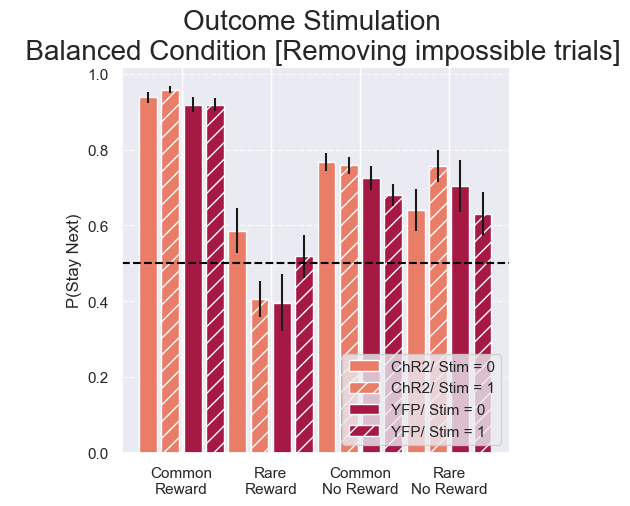

In [ ]:
plotTrialTypes (M0,M1,M0_YFP,M1_YFP, metric = 'P(Stay Next)')

sns.despine()
plt.title('Outcome Stimulation \n  Balanced Condition [Removing impossible trials]', fontsize = 20)
# add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.savefig('figuresPaper/StayNextOutcomeStimulation_balanced.svg', dpi = 300, format = 'svg')

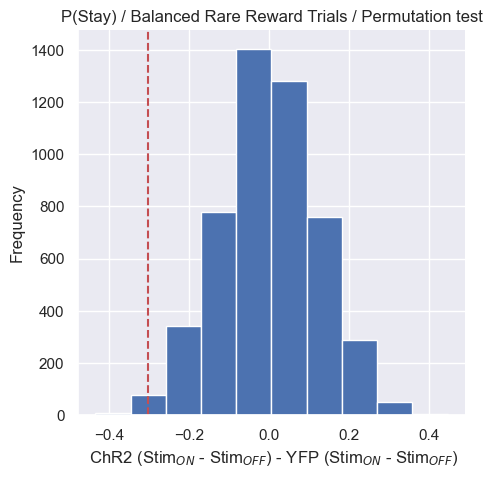

p-value:  0.0076


In [31]:
# Run additional permutation test between the difference between two groups

# no stim
rr_0_chr2 = M0[1]
rr_0_yfp = M0_YFP[1]
# stim
rr_1_chr2 = M1[1]
rr_1_yfp = M1_YFP[1]

def statistic_delta(x_1,x_0, y_1,y_0, axis = 0 ):
    return ((np.mean(x_1, axis=axis) - np.mean(x_0, axis=axis)) - (np.mean(y_1, axis=axis) - np.mean(y_0, axis=axis)) )

# run the permutation test
res = permutation_test((rr_1_chr2, rr_0_chr2, rr_1_yfp, rr_0_yfp), statistic_delta)
res

deltaChr2 = np.nanmean(rr_1_chr2) - np.nanmean(rr_0_chr2)
deltaYFP = np.nanmean(rr_1_yfp) - np.nanmean(rr_0_yfp)
delta = deltaChr2 - deltaYFP

# Shuffle  the labels for the two groups
shuffleData = []
for i in range(5000):
    # shuffle the labels

    chr2_labels = np.array([0]*len(rr_0_chr2) + [1]*len(rr_1_chr2))
    yfp_labels = np.array([0]*len(rr_0_yfp) + [1]*len(rr_1_yfp))

    
    # concatenate ch2  0 and 1
    shuf_chr2 = np.concatenate((rr_0_chr2, rr_1_chr2))
    # concatenate yfp 0 and 1
    shuf_yfp = np.concatenate((rr_0_yfp, rr_1_yfp))

    np.random.shuffle(chr2_labels)
    np.random.shuffle(yfp_labels)

    # create the shuffled data
    shuff_rr_0_chr2 = shuf_chr2[chr2_labels == 0]
    shuff_rr_1_chr2 = shuf_chr2[chr2_labels == 1]
    shuff_rr_0_yfp = shuf_yfp[yfp_labels == 0]
    shuff_rr_1_yfp = shuf_yfp[yfp_labels == 1]
    # shuffle the data
    
    # calculate the statistic for the shuffled data
    deltaShuff = statistic_delta(shuff_rr_1_chr2, shuff_rr_0_chr2, shuff_rr_1_yfp, shuff_rr_0_yfp)

    # store the result
    shuffleData.append(deltaShuff)


plt.hist(shuffleData)
plt.axvline(x=delta, color='r', linestyle='--')
plt.title('P(Stay) / Balanced Rare Reward Trials / Permutation test')
plt.xlabel(' ChR2 (Stim$_{ON}$ - Stim$_{OFF}$) - YFP (Stim$_{ON}$ - Stim$_{OFF}$)')
plt.ylabel('Frequency')
sns.despine()
plt.show()

# calculate the p-value
p_value = np.sum(np.array(shuffleData) <= delta) / len(shuffleData)
print('p-value: ', p_value)


# load results simulations sparse graph model

In [41]:
with open('/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/BlancoPozo_optimal_fit_Nov2025/model_sims_hierarchical/results_stay_prob_stimeffect_stay&forget.pkl', 'rb') as f:
    rareRewardSims = pickle.load(f)

    #stay_prob_stim,stay_prob_stim_error, stay_prob_nostim, stay_prob_nostim_error


In [43]:
rrSims_mean_stim1 = rareRewardSims[0]
rrSims_mean_stim0 = rareRewardSims[2]
rrSims_ste_stim1 = rareRewardSims[1]
rrSims_ste_stim0 = rareRewardSims[3]


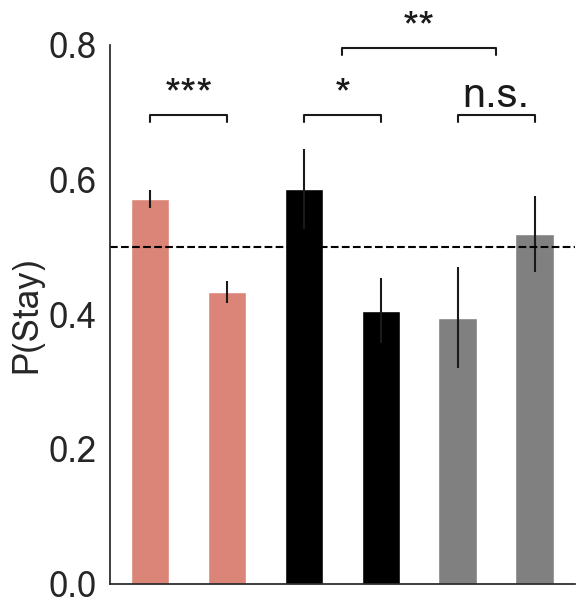

In [45]:
import matplotlib.ticker as ticker

rr_stim0_chr2 = M0[1]
rr_stim0_yfp = M0_YFP[1]

rr_stim1_chr2 = M1[1]
rr_stim1_yfp = M1_YFP[1]


plt.rcParams['hatch.linewidth'] = 5.5  # thickness of hatch lines
plt.rcParams['hatch.color'] = 'black'  # optional: change hatch color


colors = ['#DB8478', '#DB8478','#000000', '#000000', '#808080', '##808080']

fig, ax = plt.subplots(1, 1, figsize=(6,7))


mpl.rcParams['svg.fonttype'] = 'none'  # IMPORTANT
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']# size1 = 30

plt.bar(0,  rrSims_mean_stim0 , yerr= rrSims_ste_stim0, align='center', label='Simulation / Stim = 0', color = colors[0], width = 0.1)
plt.bar(0.2,  rrSims_mean_stim1 , yerr= rrSims_ste_stim1, align='center', label='Simulation / Stim = 1', color = colors[0], width = 0.1, hatch = '')

plt.bar(0.4, np.nanmean(rr_stim0_chr2), yerr=stats.sem(rr_stim0_chr2, nan_policy='omit'), align='center', label='Exp / Stim = 0', color = colors[2], width = 0.1,)
plt.bar(0.6, np.nanmean(rr_stim1_chr2), yerr=stats.sem(rr_stim1_chr2, nan_policy='omit'), align='center', label='Exp / Stim = 1', color = colors[2], width = 0.1, hatch = '')

plt.bar(0.8, np.nanmean(rr_stim0_yfp), yerr=stats.sem(rr_stim0_yfp, nan_policy='omit'), align='center', label='Control / Stim = 0', color = colors[4], width = 0.1)
plt.bar(1, np.nanmean(rr_stim1_yfp), yerr=stats.sem(rr_stim1_yfp, nan_policy='omit'), align='center', label='Control / Stim = 1', color = colors[4], width = 0.1, hatch = '')



# plt.legend(frameon=False, fontsize=15)
plt.ylabel('P(Stay)', size = 25)
plt.xlabel('', size = 25)
# plt.title('Rare Reward Trials', size = 25)

ax.yaxis.set_major_locator(ticker.MaxNLocator(4))

plt.xticks([])

plt.ylim([0,0.8])
# horizonal line in 0.5
plt.axhline(y=0.5, color='black', linestyle='--')


x1, x2 = 0, .2   # columns 'Sat' and 'Sun' (first column: 0, see plt.xticks())
y, h, col = np.nanmean(rr_stim0_chr2) + 0.1, 0.01, 'k'

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, "***", ha='center', va='bottom', color=col, fontsize = 30)


x1, x2 = 0.4,0.6    # columns 'Sat' and 'Sun' (first column: 0, see plt.xticks())
y, h, col = np.nanmean(rr_stim0_chr2) + 0.1, 0.01, 'k'

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, "*", ha='center', va='bottom', color=col, fontsize = 30)

x1, x2 = 0.8, 1   # columns 'Sat' and 'Sun' (first column: 0, see plt.xticks())
y, h, col = np.nanmean(rr_stim0_chr2) + 0.1, 0.01, 'k'

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, "n.s.", ha='center', va='bottom', color=col, fontsize = 30)


## compare in between YFP and ChR2

x1, x2 = 0.5, 0.9   # columns 'Sat' and 'Sun' (first column: 0, see plt.xticks())
y, h, col = np.nanmean(rr_stim0_chr2) + 0.2, 0.01, 'k'

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, "**", ha='center', va='bottom', color=col, fontsize = 30)
plt.tick_params(axis='both', which='major', labelsize=25)




sns.set_style('white')
sns.despine()

new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)

# save vector graphics
plt.savefig('figuresPaper/SGM2026_StayNextRareReward_Balanced_SimsExpCtrl_SkinnyVert_withSimsstay&forget_simsstay&forget_sims.pdf', dpi = 300, format = 'pdf', bbox_inches='tight')
